In [ ]:
import tensorflow as tf

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")

# 2. Normalize the image data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Reshape the training and test image data
# Images are 28x28, so they should become a 784-element array
x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))
print(f"Reshaped x_train shape: {x_train.shape}")

# 4. Convert the integer labels to one-hot encoded vectors
num_classes = 10 # MNIST has digits 0-9
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(f"One-hot encoded y_train shape: {y_train.shape}")

Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Reshaped x_train shape: (60000, 784)
One-hot encoded y_train shape: (60000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input

# 1. Define the model with Dropout layers
dropout_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

# 3. Train the model and store the history
history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Dropout model training complete.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6898 - loss: 0.9648 - val_accuracy: 0.9399 - val_loss: 0.2000
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9130 - loss: 0.3075 - val_accuracy: 0.9535 - val_loss: 0.1520
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9319 - loss: 0.2306 - val_accuracy: 0.9611 - val_loss: 0.1230
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9413 - loss: 0.2001 - val_accuracy: 0.9668 - val_loss: 0.1109
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9488 - loss: 0.1774 - val_accuracy: 0.9685 - val_loss: 0.1051
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9546 - loss: 0.1635 - val_accuracy: 0.9706 - val_loss: 0.0970
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9556 - loss: 0.1478 - val_accuracy: 0.9734 - val_loss: 0.0920
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9594 - loss: 0.1416 - val_accuracy: 0.

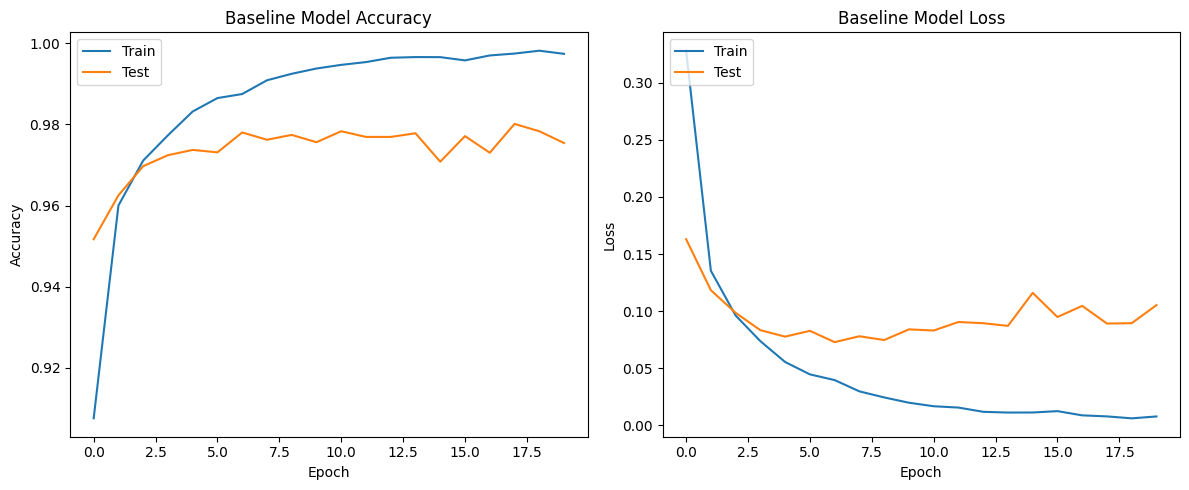

Baseline model performance curves plotted.


In [ ]:
import matplotlib.pyplot as plt

# Plotting performance curves for the baseline model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'])
plt.plot(history_baseline.history['val_accuracy'])
plt.title('Baseline Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'])
plt.plot(history_baseline.history['val_loss'])
plt.title('Baseline Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Baseline model performance curves plotted.")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input

# 1. Define the model with Dropout layers
dropout_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.4), # Added Dropout layer
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
dropout_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dropout_model.summary()

# 3. Train the model and store the history
history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Dropout model training complete.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6702 - loss: 1.0141 - val_accuracy: 0.9380 - val_loss: 0.2053
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9100 - loss: 0.3122 - val_accuracy: 0.9537 - val_loss: 0.1511
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9319 - loss: 0.2423 - val_accuracy: 0.9629 - val_loss: 0.1224
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9405 - loss: 0.2008 - val_accuracy: 0.9640 - val_loss: 0.1125
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9464 - loss: 0.1850 - val_accuracy: 0.9659 - val_loss: 0.1101
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9517 - loss: 0.1664 - val_accuracy: 0.9692 - val_loss: 0.0986
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9554 - loss: 0.1522 - val_accuracy: 0.9709 - val_loss: 0.0956
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9574 - loss: 0.1404 - val_accuracy: 0.

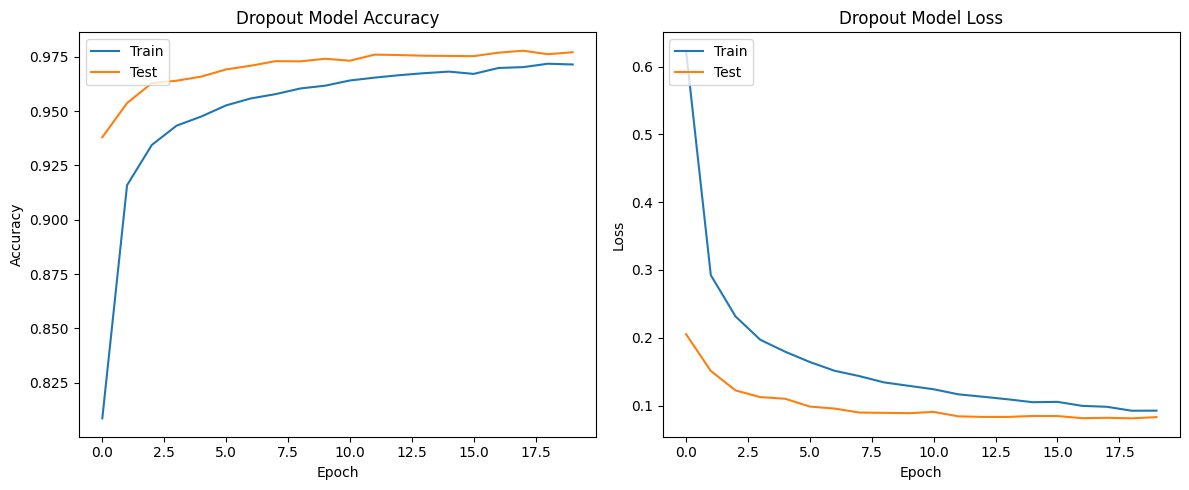

Dropout model performance curves plotted.


In [ ]:
import matplotlib.pyplot as plt

# Plotting performance curves for the dropout model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['accuracy'])
plt.plot(history_dropout.history['val_accuracy'])
plt.title('Dropout Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'])
plt.plot(history_dropout.history['val_loss'])
plt.title('Dropout Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Dropout model performance curves plotted.")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow.keras import regularizers

# 1. Define the model with L2 regularization layers
l2_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),  # Added L2 regularization
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
l2_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

l2_model.summary()

# 3. Train the model and store the history
history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("L2 Regularization model training complete.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8208 - loss: 0.8397 - val_accuracy: 0.9439 - val_loss: 0.3495
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9494 - loss: 0.3272 - val_accuracy: 0.9561 - val_loss: 0.2727
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9643 - loss: 0.2566 - val_accuracy: 0.9657 - val_loss: 0.2328
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9691 - loss: 0.2255 - val_accuracy: 0.9714 - val_loss: 0.2057
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.2054 - val_accuracy: 0.9696 - val_loss: 0.2038
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9738 - loss: 0.1910 - val_accuracy: 0.9734 - val_loss: 0.1844
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9773 - loss: 0.1743 - val_accuracy: 0.9742 - val_loss: 0.1801
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9763 - loss: 0.1737 - val_accuracy: 0.

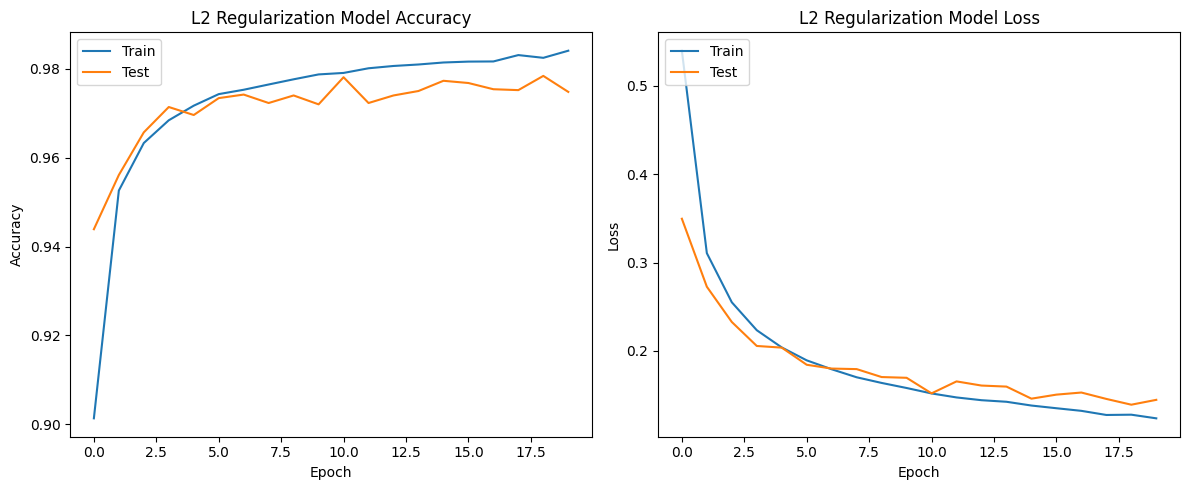

L2 Regularization model performance curves plotted.


In [ ]:
import matplotlib.pyplot as plt

# Plotting performance curves for the L2 regularization model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_l2.history['accuracy'])
plt.plot(history_l2.history['val_accuracy'])
plt.title('L2 Regularization Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_l2.history['loss'])
plt.plot(history_l2.history['val_loss'])
plt.title('L2 Regularization Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("L2 Regularization model performance curves plotted.")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras import Input

# 1. Define the model with Batch Normalization layers
bn_model = Sequential([
    Input(shape=(784,)),
    Dense(128, use_bias=False), # Use_bias=False when followed by BatchNormalization
    BatchNormalization(),
    Activation('relu'),
    Dense(64, use_bias=False), # Use_bias=False when followed by BatchNormalization
    BatchNormalization(),
    Activation('relu'),
    Dense(num_classes, activation='softmax')
])

# 2. Compile the model
bn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bn_model.summary()

# 3. Train the model and store the history
history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

print("Batch Normalization model training complete.")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 128)            │       100,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,962 (429.54 KB)

 Trainable params: 109,578 (428.04 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8505 - loss: 0.5458 - val_accuracy: 0.9589 - val_loss: 0.1424
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9701 - loss: 0.1066 - val_accuracy: 0.9735 - val_loss: 0.0886
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9815 - loss: 0.0648 - val_accuracy: 0.9760 - val_loss: 0.0810
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9864 - loss: 0.0469 - val_accuracy: 0.9774 - val_loss: 0.0743
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9901 - loss: 0.0348 - val_accuracy: 0.9758 - val_loss: 0.0818
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9923 - loss: 0.0268 - val_accuracy: 0.9765 - val_loss: 0.0726
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9927 - loss: 0.0239 - val_accuracy: 0.9748 - val_loss: 0.0874
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9943 - loss: 0.0198 - val_accuracy: 0.

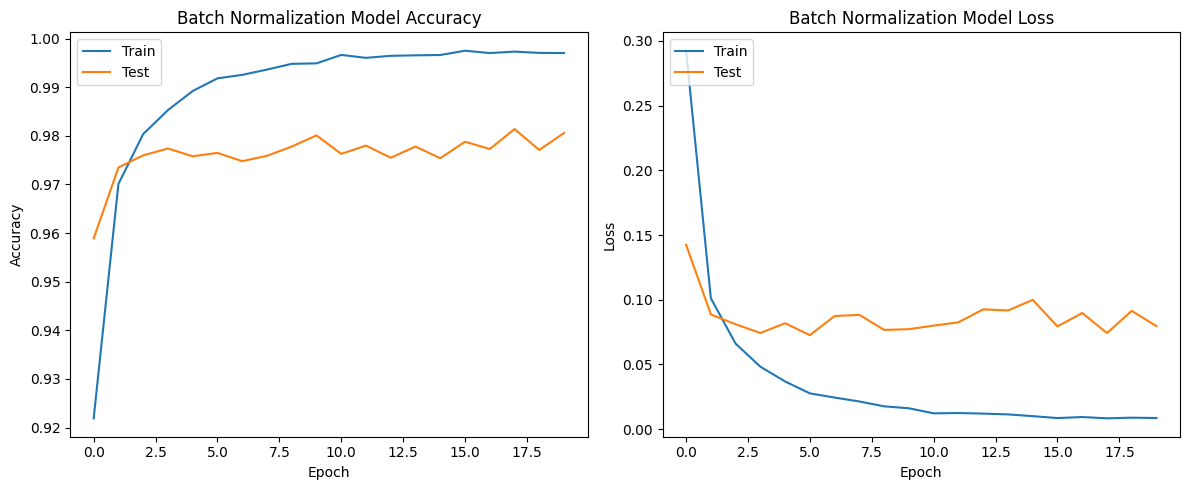

Batch Normalization model performance curves plotted.


In [ ]:
import matplotlib.pyplot as plt

# Plotting performance curves for the Batch Normalization model
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_bn.history['accuracy'])
plt.plot(history_bn.history['val_accuracy'])
plt.title('Batch Normalization Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_bn.history['loss'])
plt.plot(history_bn.history['val_loss'])
plt.title('Batch Normalization Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

print("Batch Normalization model performance curves plotted.")

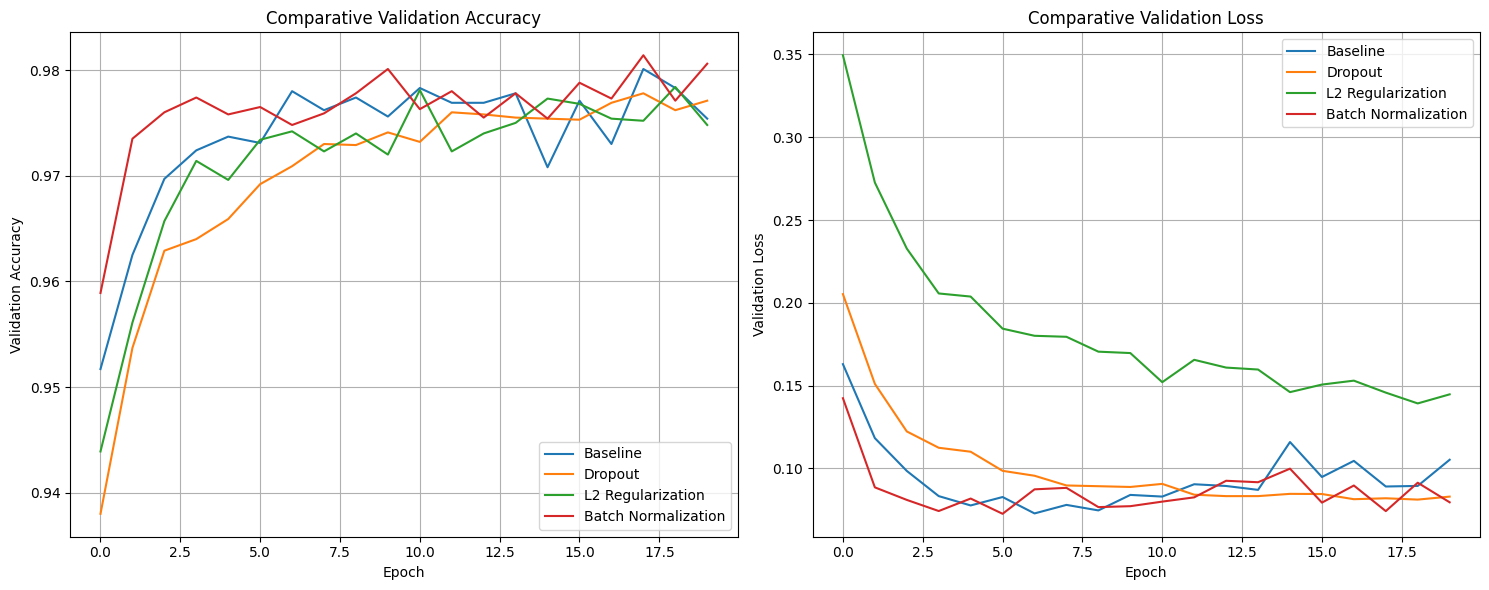

Comparative performance curves plotted.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Subplot 1: Comparative Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2 Regularization')
plt.plot(history_bn.history['val_accuracy'], label='Batch Normalization')
plt.title('Comparative Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Subplot 2: Comparative Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2 Regularization')
plt.plot(history_bn.history['val_loss'], label='Batch Normalization')
plt.title('Comparative Validation Loss')
plt.ylabel('Validation Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Comparative performance curves plotted.")